# Data Preparation for GNSS PW 
To reshape the data so each row represents a unique (station, timestamp) with columns for:
- Precipitable Water (PW)
- ERA5 Reference PW (PW_ERA5)
- Zenith Total Delay (ZTD)
- Station coordinates (latitude, longitude, elevation)
- Time features (hour, day, month, season)
The resulting DataFrame will be used for further AI/ML modeling.

In [3]:
# Import required libraries
import pandas as pd
import numpy as np
from pathlib import Path

In [4]:
# Define the data folder and file paths
data_folder = Path('iic_dataset_2023')
csv_files = [
    data_folder / '1jan-2023.csv',
    data_folder / '2feb-2023.csv',
    data_folder / '3mar-2023.csv',
    data_folder / '4apr-2023.csv',
    data_folder / '5may-2023.csv',
    data_folder / '6jun-2023.csv',
    data_folder / '7jul-2023.csv',
    data_folder / '8aug-2023.csv',
    data_folder / '9sep-2023.csv',
    data_folder / '10oct-2023.csv'
 ]

# Try reading each file and print the first few lines to diagnose issues
for f in csv_files:
    print(f'\n--- Preview of {f} ---')
    try:
        with open(f, 'r', encoding='utf-8') as file:
            for i in range(8):
                print(file.readline().strip())
    except Exception as e:
        print(f'Error reading {f}: {e}')

# Read CSVs, skipping comment lines and handling bad lines
df_list = []
for f in csv_files:
    try:
        df = pd.read_csv(f, comment='#', on_bad_lines='skip', engine='python')
        df_list.append(df)
        print(f'Loaded {f} with shape {df.shape}')
    except Exception as e:
        print(f'Error loading {f} with pandas: {e}')

if df_list:
    raw_df = pd.concat(df_list, ignore_index=True)
    print(f'Total rows loaded: {len(raw_df)}')
    display(raw_df.head())
else:
    print('No data loaded. Please check the CSV files for format issues.')


--- Preview of iic_dataset_2023\1jan-2023.csv ---
index,observation_id,report_id,observed_variable,observation_value,units,primary_station_id,height_of_station_above_sea_level,report_timestamp,city,uncertainty_type1,uncertainty_type5,uncertainty_units1,uncertainty_units5,uncertainty_value1,uncertainty_value5,longitude,latitude
0,62340385,483,precipitable_water_column,8.77,kg m-2,ROTH00ATA,30.87343,01-01-2023 00:00,Rothera Station,1,5,NA,kg m-2,nan,0.45,-68.125755,-67.571396
1,62340385,483,precipitable_water_column_era5,7.73,kg m-2,ROTH00ATA,30.87343,01-01-2023 00:00,Rothera Station,1,5,NA,NA,nan,nan,-68.125755,-67.571396
2,62340385,483,zenith_total_delay,2.2881,m,ROTH00ATA,30.87343,01-01-2023 00:00,Rothera Station,1,5,m,NA,0.0022,nan,-68.125755,-67.571396
3,62340193,410,precipitable_water_column,9.26,kg m-2,PALM00ATA,14.05616,01-01-2023 00:00,Palmer Station,1,5,NA,kg m-2,nan,0.42,-64.051125,-64.77509
4,62340193,410,precipitable_water_column_era5,8.82,kg m-2,PALM00ATA,14.05616,01-01-20

,index,observation_id,report_id,observed_variable,observation_value,units,primary_station_id,height_of_station_above_sea_level,report_timestamp,city,uncertainty_type1,uncertainty_type5,uncertainty_units1,uncertainty_units5,uncertainty_value1,uncertainty_value5,longitude,latitude
0,0,62340385,483,precipitable_water_column,8.7700,kg m-2,ROTH00ATA,30.87343,01-01-2023 00:00,Rothera Station,1,5,NaN,kg m-2,NaN,0.45,-68.125755,-67.571396
1,1,62340385,483,precipitable_water_column_era5,7.7300,kg m-2,ROTH00ATA,30.87343,01-01-2023 00:00,Rothera Station,1,5,NaN,NaN,NaN,NaN,-68.125755,-67.571396
2,2,62340385,483,zenith_total_delay,2.2881,m,ROTH00ATA,30.87343,01-01-2023 00:00,Rothera Station,1,5,m,NaN,0.0022,NaN,-68.125755,-67.571396
3,3,62340193,410,precipitable_water_column,9.2600,kg m-2,PALM00ATA,14.05616,01-01-2023 00:00,Palmer Station,1,5,NaN,kg m-2,NaN,0.42,-64.051125,-64.775090
4,4,62340193,410,precipitable_water_column_era5,8.8200,kg m-2,PALM00ATA,14.05616,01-01-2023 00:00,Palmer Station,1,5,NaN,NaN,NaN,NaN,-64.051125,-64.775090


In [5]:
# Pivot the data to have one row per (station, timestamp) and columns for PW, PW_ERA5, ZTD
if 'raw_df' in globals():
    pivot_df = raw_df.pivot_table(
        index=['primary_station_id', 'report_timestamp'],
        columns='observed_variable',
        values='observation_value',
        aggfunc='first'
    ).reset_index()

    # Merge back the static station info and coordinates
    # Only use columns that exist in raw_df to avoid KeyError
    base_static_cols = ['primary_station_id','city','height_of_station_above_sea_level','longitude','latitude']
    static_cols = [col for col in base_static_cols if col in raw_df.columns]
    static_info = raw_df[static_cols].drop_duplicates('primary_station_id')
    pivot_df = pivot_df.merge(static_info, on='primary_station_id', how='left')

    # Rename columns for clarity
    pivot_df = pivot_df.rename(columns={
        'precipitable_water_column': 'PW',
        'precipitable_water_column_era5': 'PW_ERA5',
        'zenith_total_delay': 'ZTD',
        'height_of_station_above_sea_level': 'station_elevation'	
    })

    display(pivot_df.head())
else:
    print('raw_df is not defined. Please ensure the previous cell loaded the data successfully before running this cell.')

,primary_station_id,report_timestamp,PW,PW_ERA5,ZTD,city,station_elevation,longitude,latitude
0,ABMF00GLP,01-01-2023 00:00,35.99,33.87,2.5366,Les Abymes,15.25247,-61.52754,16.262304
1,ABMF00GLP,01-01-2023 01:00,33.70,35.33,2.5238,Les Abymes,15.25247,-61.52754,16.262304
2,ABMF00GLP,01-01-2023 02:00,33.75,36.37,2.5243,Les Abymes,15.25247,-61.52754,16.262304
3,ABMF00GLP,01-01-2023 03:00,34.96,36.28,2.5309,Les Abymes,15.25247,-61.52754,16.262304
4,ABMF00GLP,01-01-2023 04:00,35.27,35.61,2.5315,Les Abymes,15.25247,-61.52754,16.262304


In [6]:
# Parse report_timestamp as datetime and extract time features
if 'pivot_df' in globals():
    # Try parsing with dayfirst=True and errors='coerce' to handle mixed formats
    pivot_df['report_timestamp'] = pd.to_datetime(pivot_df['report_timestamp'], dayfirst=True, errors='coerce')

    # Show rows where parsing failed
    failed = pivot_df[pd.isnull(pivot_df['report_timestamp'])]
    if not failed.empty:
        print('Warning: Some timestamps could not be parsed. Showing a few examples:')
        display(failed[['primary_station_id', 'report_timestamp']].head())

    pivot_df['hour'] = pivot_df['report_timestamp'].dt.hour
    pivot_df['day'] = pivot_df['report_timestamp'].dt.day
    pivot_df['month'] = pivot_df['report_timestamp'].dt.month

    # Define season based on month
    def get_season(month):
        if month in [12, 1, 2]:
            return 'Winter'
        elif month in [3, 4, 5]:
            return 'Spring'
        elif month in [6, 7, 8]:
            return 'Summer'
        else:
            return 'Autumn'

    pivot_df['season'] = pivot_df['month'].apply(get_season)

    display(pivot_df.head())
else:
    print('pivot_df is not defined. Please ensure the previous cell ran successfully before running this cell.')

,primary_station_id,report_timestamp,PW,PW_ERA5,ZTD,city,station_elevation,longitude,latitude,hour,day,month,season
0,ABMF00GLP,2023-01-01 00:00:00,35.99,33.87,2.5366,Les Abymes,15.25247,-61.52754,16.262304,0,1,1,Winter
1,ABMF00GLP,2023-01-01 01:00:00,33.70,35.33,2.5238,Les Abymes,15.25247,-61.52754,16.262304,1,1,1,Winter
2,ABMF00GLP,2023-01-01 02:00:00,33.75,36.37,2.5243,Les Abymes,15.25247,-61.52754,16.262304,2,1,1,Winter
3,ABMF00GLP,2023-01-01 03:00:00,34.96,36.28,2.5309,Les Abymes,15.25247,-61.52754,16.262304,3,1,1,Winter
4,ABMF00GLP,2023-01-01 04:00:00,35.27,35.61,2.5315,Les Abymes,15.25247,-61.52754,16.262304,4,1,1,Winter


# Data Visualization.

- Visualize the spatial distribution of GNSS stations
- Plot time series of Precipitable Water (PW) and Zenith Total Delay (ZTD) for a few stations
- Check the correlation between ZTD and PW

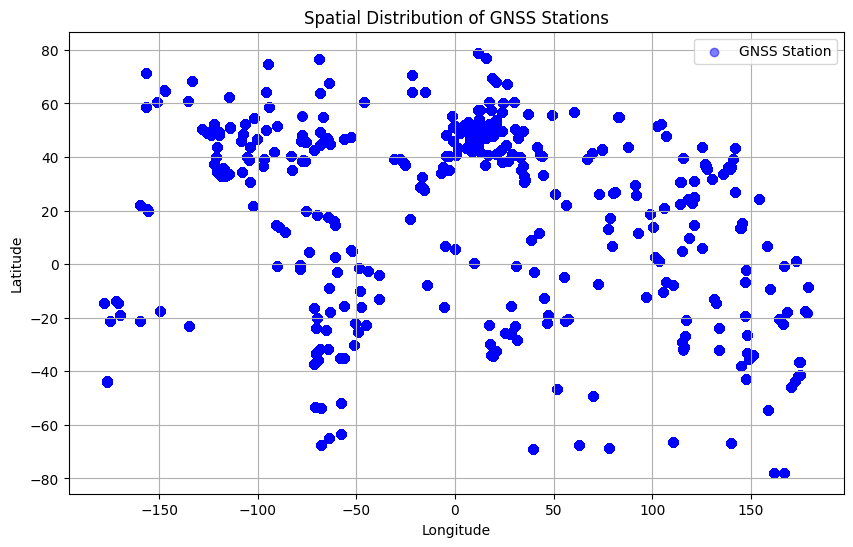

In [7]:
# Visualize spatial distribution of GNSS stations
import matplotlib.pyplot as plt

if 'pivot_df' in globals():
    plt.figure(figsize=(10,6))
    plt.scatter(pivot_df['longitude'], pivot_df['latitude'], alpha=0.5, c='blue', label='GNSS Station')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.title('Spatial Distribution of GNSS Stations')
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print('pivot_df is not defined. Please run the previous cells first.')

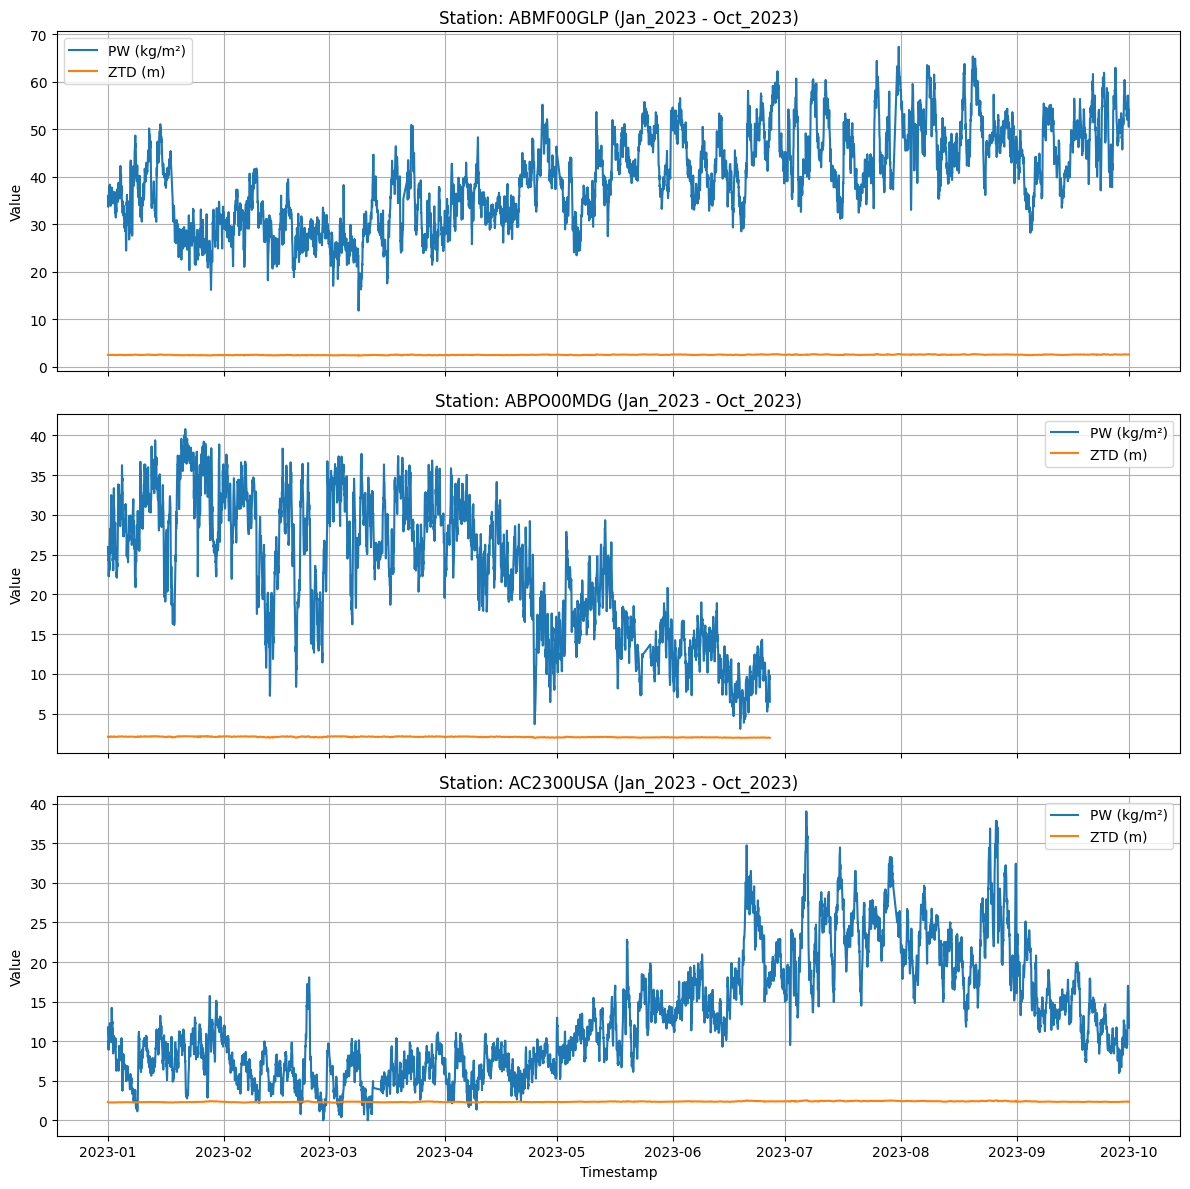

In [ ]:
# Plot time series of PW and ZTD for a few stations (January to September only)
if 'pivot_df' in globals():
    # Filter for January to September only
    months_range = list(range(1, 10))
    jan_sep_df = pivot_df[pivot_df['month'].isin(months_range)] if 'month' in pivot_df.columns else pivot_df.copy()
    sample_stations = jan_sep_df['primary_station_id'].dropna().unique()[:3]  # Pick 3 stations
    fig, axs = plt.subplots(len(sample_stations), 1, figsize=(12, 4*len(sample_stations)), sharex=True)
    if len(sample_stations) == 1:
        axs = [axs]
    for i, station in enumerate(sample_stations):
        station_data = jan_sep_df[jan_sep_df['primary_station_id'] == station].sort_values('report_timestamp')
        # Drop rows where PW or ZTD is missing or constant
        station_data = station_data.dropna(subset=['PW', 'ZTD'])
        if station_data['PW'].nunique() <= 1 or station_data['ZTD'].nunique() <= 1:
            axs[i].text(0.5, 0.5, 'No variation in PW or ZTD', ha='center', va='center', transform=axs[i].transAxes)
            axs[i].set_title(f'Station: {station} (No variation)')
            axs[i].set_axis_off()
            continue
        axs[i].plot(station_data['report_timestamp'], station_data['PW'], label='PW (kg/m²)')
        axs[i].plot(station_data['report_timestamp'], station_data['ZTD'], label='ZTD (m)')
        axs[i].set_title(f'Station: {station} (Jan_2023 - Oct_2023)')
        axs[i].set_ylabel('Value')
        axs[i].legend()
        axs[i].grid(True)
    plt.xlabel('Timestamp')
    plt.tight_layout()
    plt.show()
else:
    print('pivot_df is not defined. Please run the previous cells first.')


Correlation between PW and ZTD: 0.703


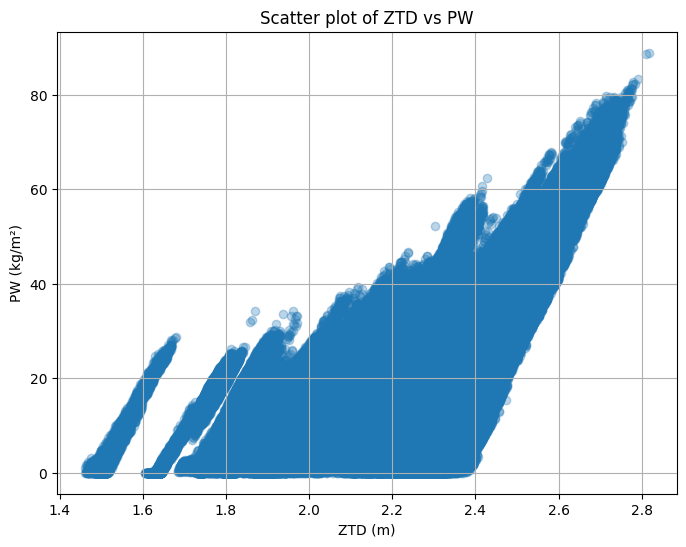

In [ ]:
# Check correlation between ZTD and PW
if 'pivot_df' in globals():
    corr_df = pivot_df[['PW', 'ZTD']].dropna()
    correlation = corr_df['PW'].corr(corr_df['ZTD'])
    print(f'Correlation between PW and ZTD: {correlation:.3f}')

    plt.figure(figsize=(8,6))
    plt.scatter(corr_df['ZTD'], corr_df['PW'], alpha=0.3)
    plt.xlabel('ZTD (m)')
    plt.ylabel('PW (kg/m²)')
    plt.title('Scatter plot of ZTD vs PW')
    plt.grid(True)
    plt.show()
else:
    print('pivot_df is not defined. Please run the previous cells first.')


Removed 58890 outliers using IQR method.


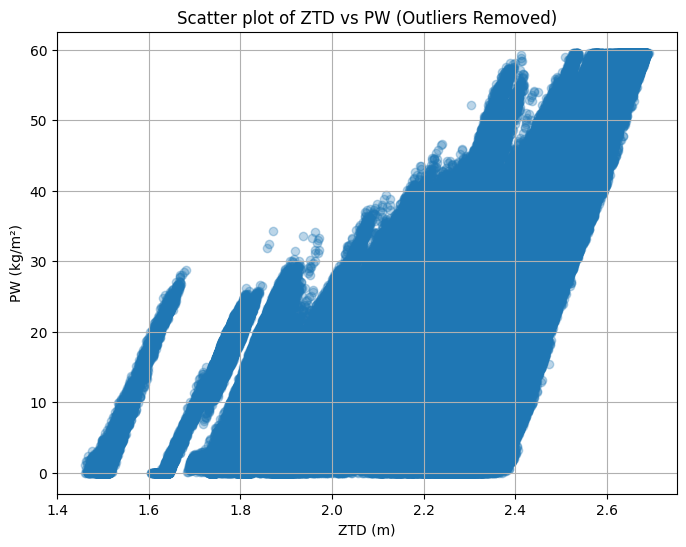

In [ ]:
# Remove outliers in PW using the IQR method and plot again
if 'pivot_df' in globals():
    corr_df = pivot_df[['PW', 'ZTD']].dropna()
    Q1 = corr_df['PW'].quantile(0.25)
    Q3 = corr_df['PW'].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    filtered_df = corr_df[(corr_df['PW'] >= lower_bound) & (corr_df['PW'] <= upper_bound)]
    print(f"Removed {len(corr_df) - len(filtered_df)} outliers using IQR method.")
    # Plot
    import matplotlib.pyplot as plt
    plt.figure(figsize=(8,6))
    plt.scatter(filtered_df['ZTD'], filtered_df['PW'], alpha=0.3)
    plt.xlabel('ZTD (m)')
    plt.ylabel('PW (kg/m²)')
    plt.title('Scatter plot of ZTD vs PW (Outliers Removed)')
    plt.grid(True)
    plt.show()

else:
    print('pivot_df is not defined. Please run the previous cells first.')

Removed 7 outliers using DBSCAN (on subsample).


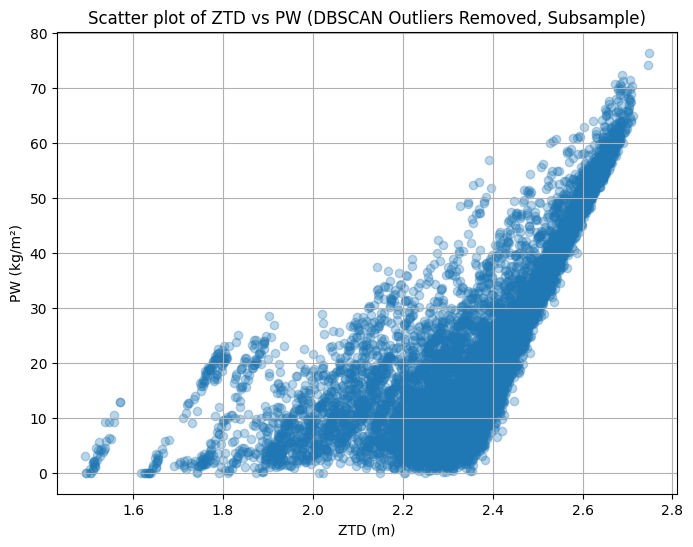

In [ ]:
# Remove outliers in PW and ZTD using DBSCAN on a subsample and plot again
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
if 'pivot_df' in globals():
    corr_df = pivot_df[['PW', 'ZTD']].dropna()
    # Subsample if too large (e.g., > 10,000 points)
    max_points = 10000
    if len(corr_df) > max_points:
        corr_df_sample = corr_df.sample(n=max_points, random_state=42)
    else:
        corr_df_sample = corr_df
    # Standardize features for DBSCAN
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(corr_df_sample[['PW', 'ZTD']])
    # DBSCAN clustering
    db = DBSCAN(eps=0.5, min_samples=30)
    labels = db.fit_predict(X_scaled)
    if len(corr_df) > max_points:
        corr_df_sample = corr_df.sample(n=max_points, random_state=42)
    else:
        corr_df_sample = corr_df
    # Standardize features for DBSCAN
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(corr_df_sample[['PW', 'ZTD']])
    # DBSCAN clustering
    db = DBSCAN(eps=0.5, min_samples=22)
    labels = db.fit_predict(X_scaled)
    # Keep only core and border points (label != -1)
    filtered_df = corr_df_sample[labels != -1]
    print(f"Removed {len(corr_df_sample) - len(filtered_df)} outliers using DBSCAN (on subsample).")
    # Plot
    import matplotlib.pyplot as plt
    plt.figure(figsize=(8,6))
    plt.scatter(filtered_df['ZTD'], filtered_df['PW'], alpha=0.3)
    plt.xlabel('ZTD (m)')
    plt.ylabel('PW (kg/m²)')
    plt.title('Scatter plot of ZTD vs PW (DBSCAN Outliers Removed, Subsample)')
    plt.grid(True)
    plt.show()
else:
    print('pivot_df is not defined. Please run the previous cells first.')

# Model Building: Predicting PW at a Specific Location/Time
We will use the following features to predict Precipitable Water (PW):
- Zenith Total Delay (ZTD)
- Latitude, Longitude, Height
- Time variables (hour, day, month, season)
We will train and compare two models: Random Forest and XGBoost.

In [12]:
# Prepare features and target for ML models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

if 'pivot_df' in globals():
    # Drop rows with missing values in required columns
    model_df = pivot_df.dropna(subset=['PW', 'ZTD', 'latitude', 'longitude', 'station_elevation', 'hour', 'day', 'month', 'season'])

    # Encode season as categorical
    le = LabelEncoder()
    model_df['season_enc'] = le.fit_transform(model_df['season'])
    # Features and target
    features = ['ZTD', 'latitude', 'longitude', 'station_elevation', 'hour', 'day', 'month', 'season_enc']
    X = model_df[features]
    y = model_df['PW']

    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    print(f'Train shape: {X_train.shape}, Test shape: {X_test.shape}')
else:
    print('pivot_df is not defined. Please run the previous cells first.')

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_7636\2498878223.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  model_df['season_enc'] = le.fit_transform(model_df['season'])


Train shape: (2390767, 8), Test shape: (597692, 8)


--- Random Forest ---
MAE: 0.542
RMSE: 0.830
R2: 0.997

--- XGBoost ---
MAE: 1.289
RMSE: 1.738
R2: 0.988



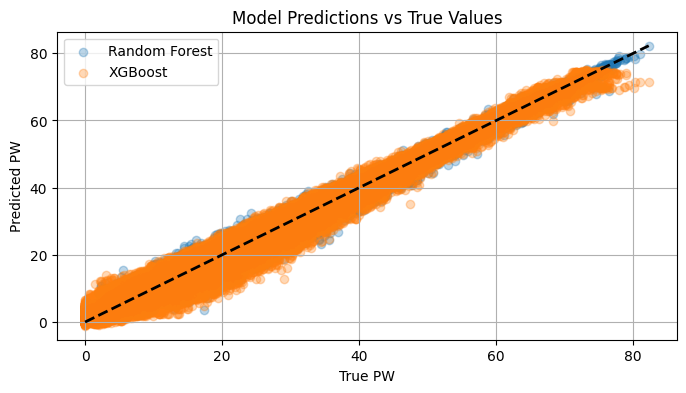

In [ ]:
# Train and evaluate Random Forest and XGBoost models
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import numpy as np

if 'X_train' in globals():
    # Random Forest
    rf = RandomForestRegressor(n_estimators=100, random_state=42)
    rf.fit(X_train, y_train)
    y_pred_rf = rf.predict(X_test)

    # XGBoost
    xgb_model = xgb.XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
    xgb_model.fit(X_train, y_train)
    y_pred_xgb = xgb_model.predict(X_test)

    # Evaluation function
    def print_metrics(y_true, y_pred, name):
        print(f'--- {name} ---')
        print(f'MAE: {mean_absolute_error(y_true, y_pred):.3f}')
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        print(f'RMSE: {rmse:.3f}')
        print(f'R2: {r2_score(y_true, y_pred):.3f}\n')

    print_metrics(y_test, y_pred_rf, 'Random Forest')
    print_metrics(y_test, y_pred_xgb, 'XGBoost')

    # Compare visually
    import matplotlib.pyplot as plt
    plt.figure(figsize=(8,4))
    plt.scatter(y_test, y_pred_rf, alpha=0.3, label='Random Forest')
    plt.scatter(y_test, y_pred_xgb, alpha=0.3, label='XGBoost')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
    plt.xlabel('True PW')
    plt.ylabel('Predicted PW')
    plt.title('Model Predictions vs True Values')
    plt.legend()
    plt.grid(True)
    plt.show()

else:
    print('X_train is not defined. Please run the previous cell first.')



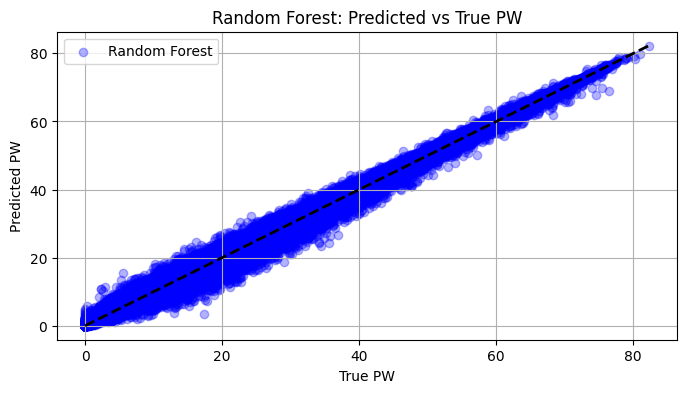

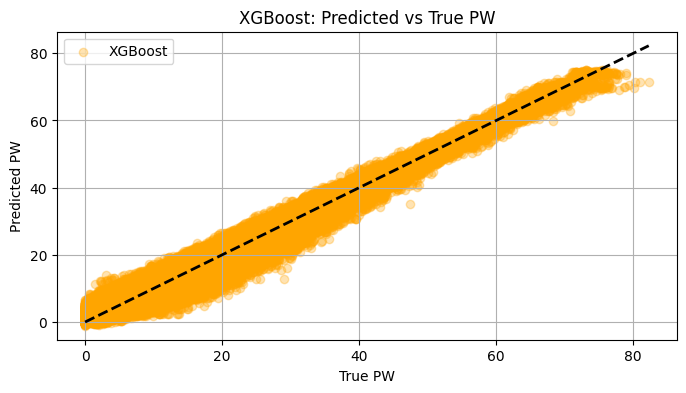

In [14]:
# Plot Random Forest and XGBoost predictions vs True PW separately
if 'X_train' in globals() and 'y_test' in globals() and 'y_pred_rf' in globals() and 'y_pred_xgb' in globals():
    import matplotlib.pyplot as plt
    # Random Forest
    plt.figure(figsize=(8,4))
    plt.scatter(y_test, y_pred_rf, alpha=0.3, color='blue', label='Random Forest')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
    plt.xlabel('True PW')
    plt.ylabel('Predicted PW')
    plt.title('Random Forest: Predicted vs True PW')
    plt.legend()
    plt.grid(True)
    plt.show()

    # XGBoost
    plt.figure(figsize=(8,4))
    plt.scatter(y_test, y_pred_xgb, alpha=0.3, color='orange', label='XGBoost')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
    plt.xlabel('True PW')
    plt.ylabel('Predicted PW')
    plt.title('XGBoost: Predicted vs True PW')
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print('Model predictions not available. Please run the previous cells first.')

# B. Spatial Interpolation (PW at Unmeasured Locations) using Random Forest

In [15]:
# Spatial Interpolation of PW using Random Forest
from sklearn.ensemble import RandomForestRegressor
import numpy as np

# Define 'known' stations with all required spatial info
if 'pivot_df' in globals():
    known = pivot_df.dropna(subset=['longitude', 'latitude', 'station_elevation', 'PW'])
    # Train Random Forest on spatial features (longitude, latitude, elevation)
    X_spatial = known[['longitude', 'latitude', 'station_elevation']].values
    y_spatial = known['PW'].values
    rf_spatial = RandomForestRegressor(n_estimators=100, random_state=42)
    rf_spatial.fit(X_spatial, y_spatial)
    print('Random Forest spatial model trained.')
    # Predict at a new location (mean of all stations + 0.1 for lon/lat, mean elevation)
    new_lon = known['longitude'].mean() + 0.1
    new_lat = known['latitude'].mean() + 0.1
    new_elev = known['station_elevation'].mean()
    new_point_rf = np.array([[new_lon, new_lat, new_elev]])
    pred_pw_rf_spatial = rf_spatial.predict(new_point_rf)[0]
    print(f'Random Forest-predicted PW at ({new_lon:.2f}, {new_lat:.2f}, elev={new_elev:.2f}): {pred_pw_rf_spatial:.2f} kg/m²')
else:
    print('pivot_df is not defined. Please run the previous cells first.')

Random Forest spatial model trained.
Random Forest-predicted PW at (3.54, 21.09, elev=403.96): 27.36 kg/m²


# C. Time-Series PW Prediction
We will use lagged features (previous PW, ZTD, ERA5 PW, and time variables) to predict future PW for a station using simple regression.

Station ABMF00GLP | R2: 0.952 | MAE: 1.270 | RMSE: 1.685


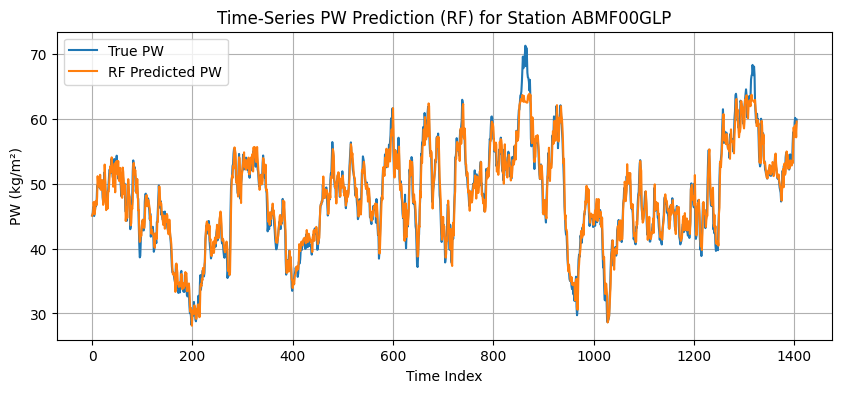

Station ABPO00MDG | R2: 0.901 | MAE: 0.812 | RMSE: 1.002


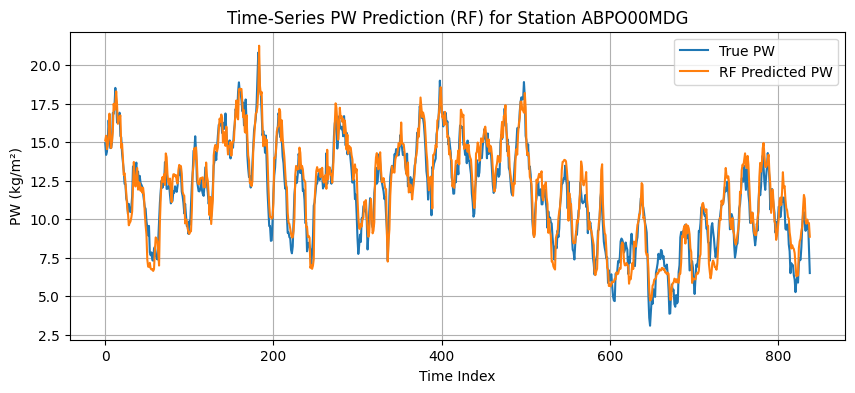

Station AC2300USA | R2: 0.979 | MAE: 0.587 | RMSE: 0.780


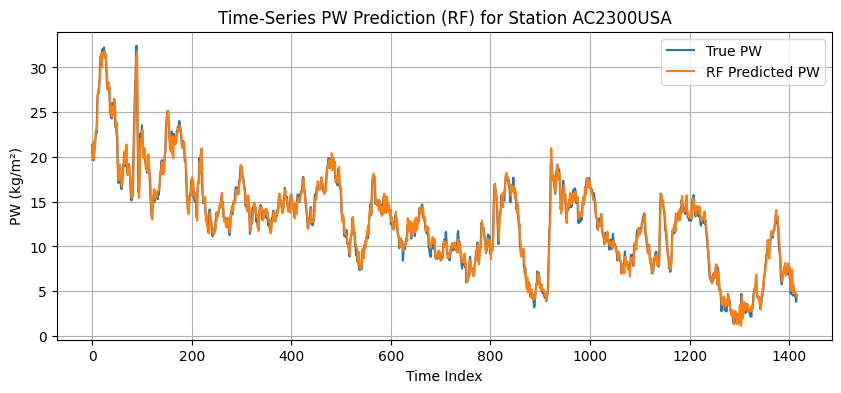

Station AC2400USA | R2: 0.961 | MAE: 0.655 | RMSE: 0.901


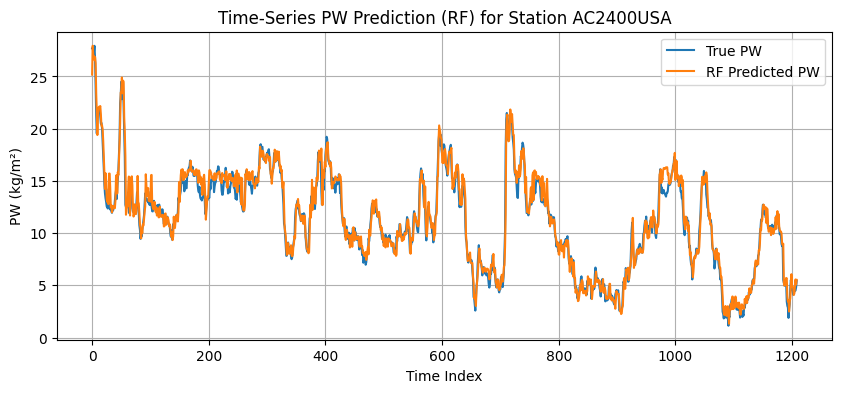

Station ACRG00GHA | R2: 0.873 | MAE: 0.882 | RMSE: 1.165


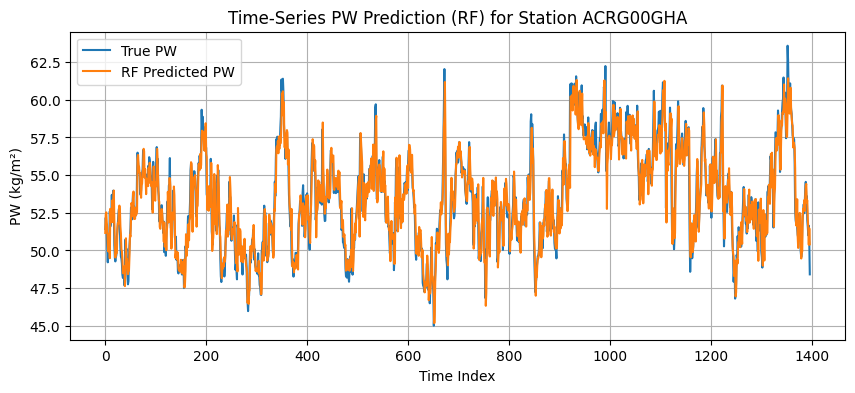

Station ACSO00USA | R2: 0.982 | MAE: 0.835 | RMSE: 1.103


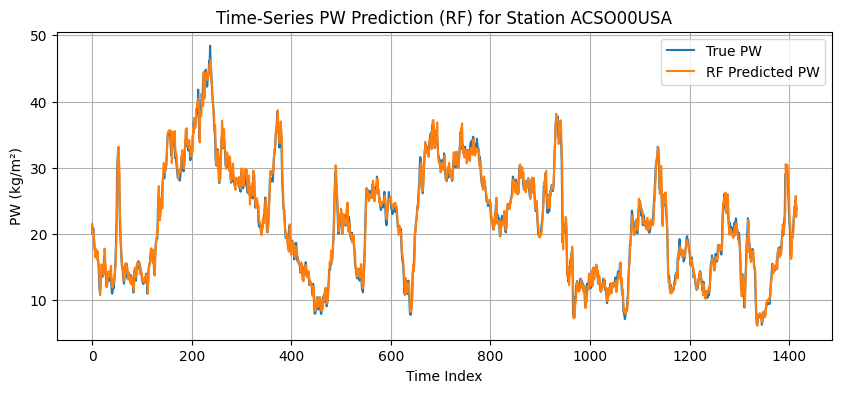

Station ADIS00ETH | R2: 0.931 | MAE: 0.875 | RMSE: 1.128


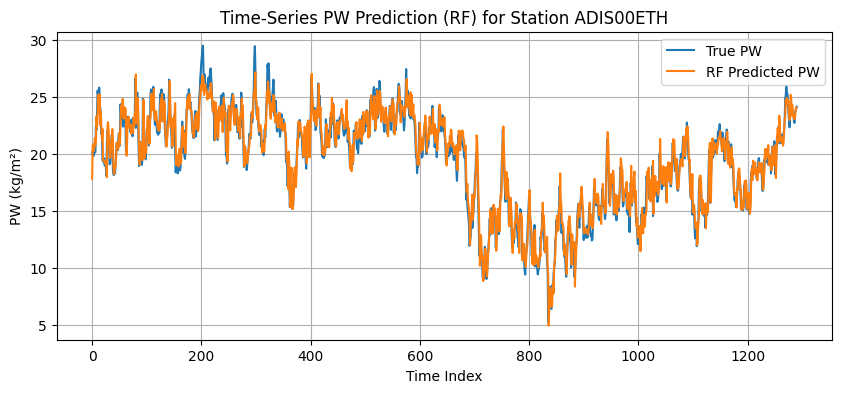

Station AGGO00ARG | R2: 0.983 | MAE: 0.841 | RMSE: 1.123


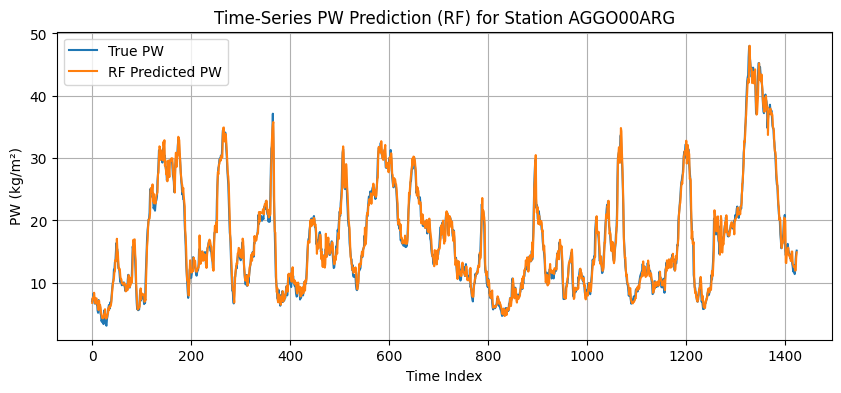

Station AIRA00JPN | R2: 0.989 | MAE: 1.170 | RMSE: 1.547


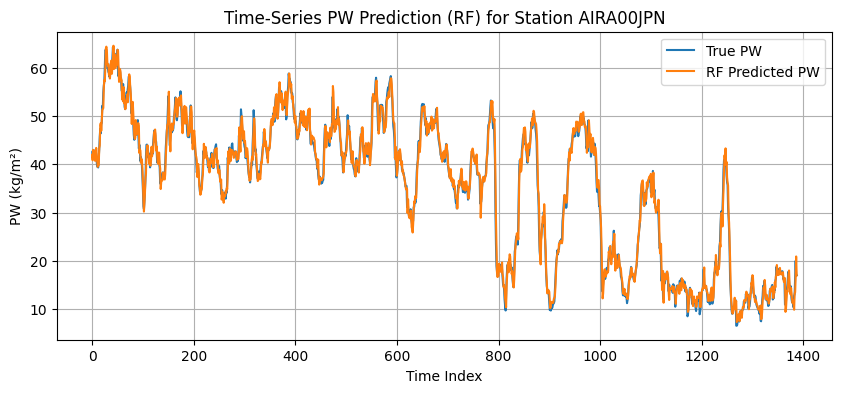

Station AJAC00FRA | R2: 0.948 | MAE: 1.011 | RMSE: 1.330


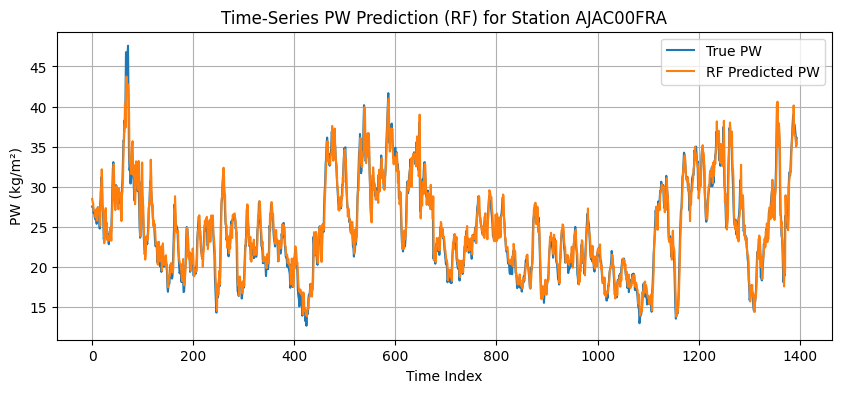

Station ALBH00CAN | R2: 0.971 | MAE: 0.762 | RMSE: 1.043


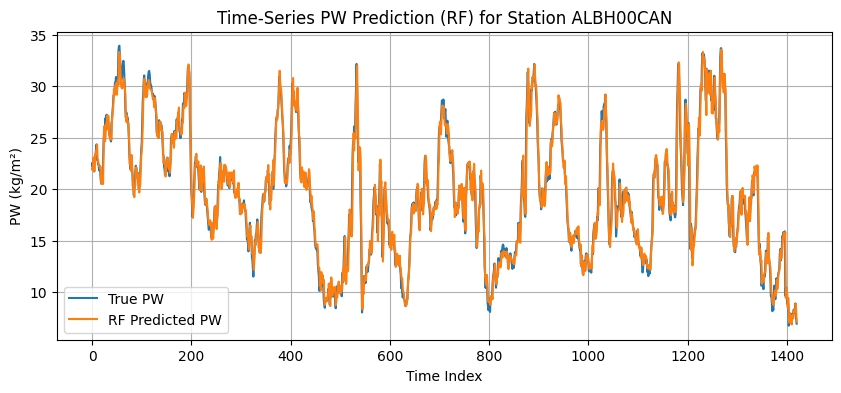

Station ALGO00CAN | R2: 0.975 | MAE: 0.788 | RMSE: 1.068


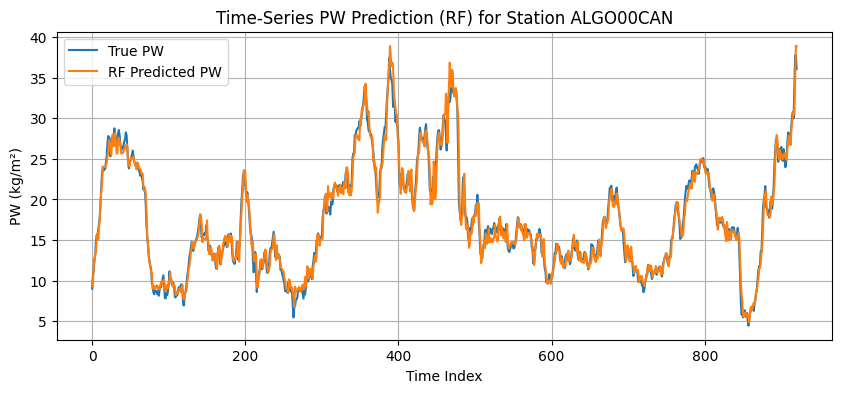

Station ALIC00AUS | R2: 0.967 | MAE: 0.593 | RMSE: 0.810


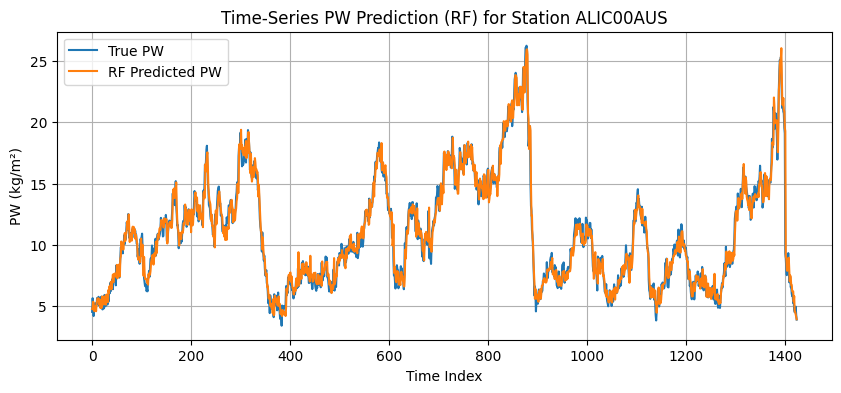

Station AMC400USA | R2: 0.951 | MAE: 0.751 | RMSE: 0.981


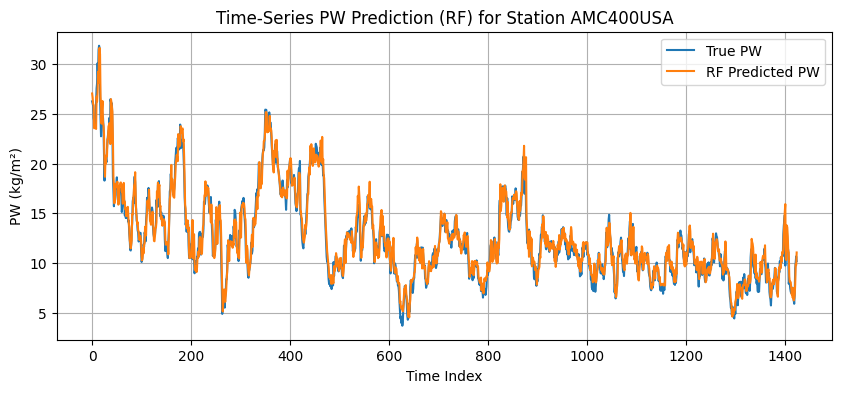

Station ANK200TUR | R2: 0.918 | MAE: 0.905 | RMSE: 1.516


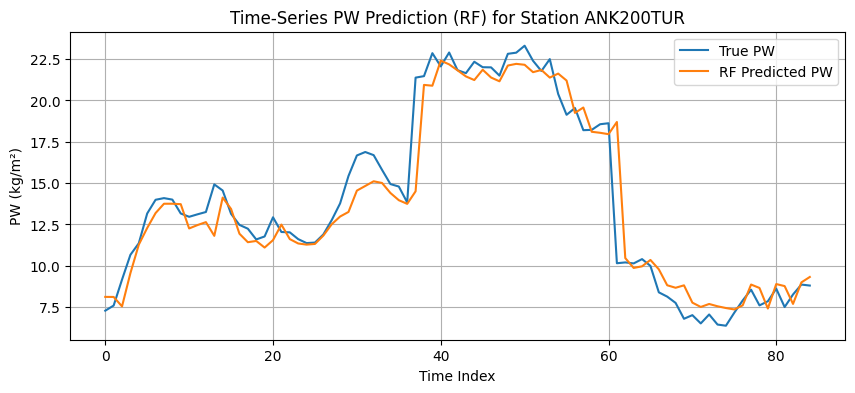

Station ANMG00MYS | R2: 0.856 | MAE: 1.293 | RMSE: 1.703


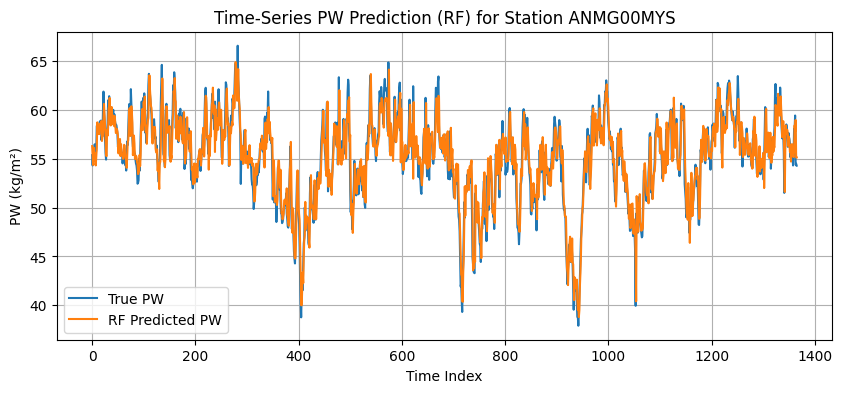

Station ANTC00CHL | R2: 0.954 | MAE: 0.669 | RMSE: 0.864


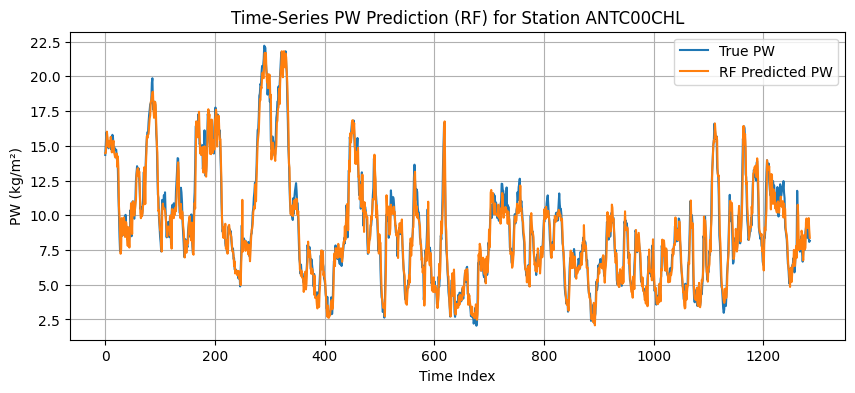

Station ANTF00CHL | R2: 0.864 | MAE: 0.642 | RMSE: 0.843


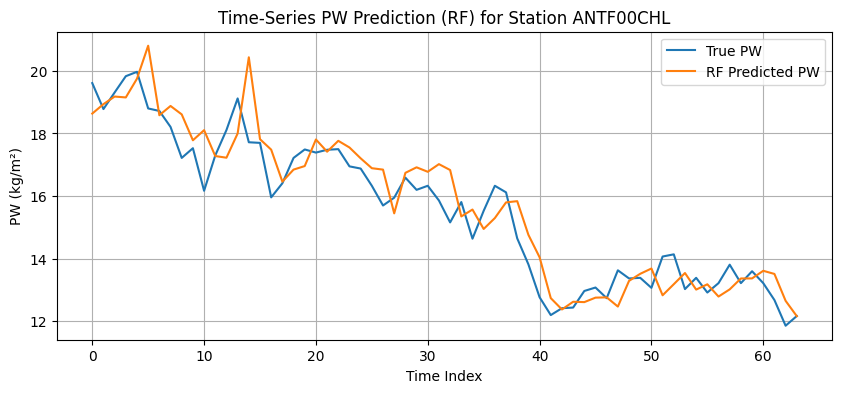

Station AREG00PER | R2: 0.982 | MAE: 0.571 | RMSE: 0.765


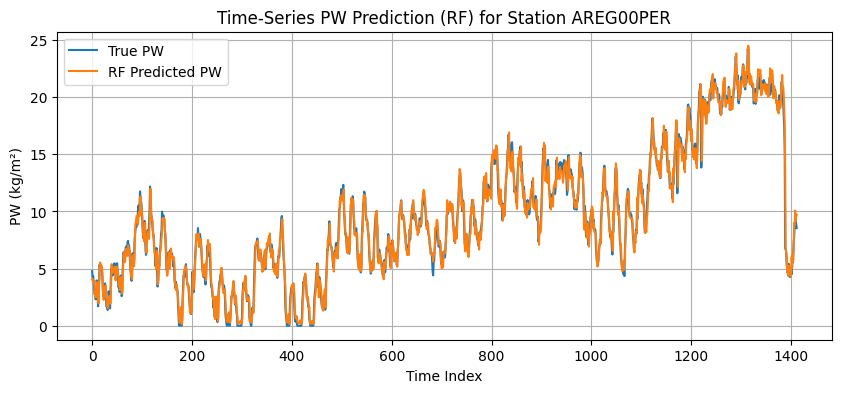

Station AREQ00PER | R2: 0.980 | MAE: 0.586 | RMSE: 0.805


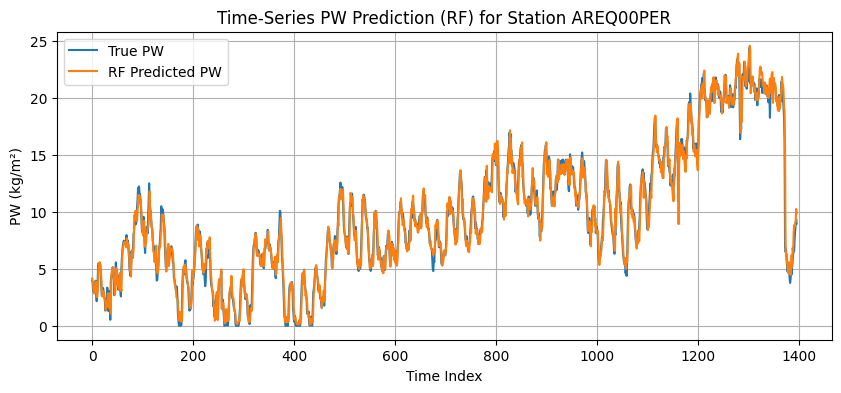


Summary for first 20 stations:
Station               R2      MAE     RMSE
ABMF00GLP          0.952    1.270    1.685
ABPO00MDG          0.901    0.812    1.002
AC2300USA          0.979    0.587    0.780
AC2400USA          0.961    0.655    0.901
ACRG00GHA          0.873    0.882    1.165
ACSO00USA          0.982    0.835    1.103
ADIS00ETH          0.931    0.875    1.128
AGGO00ARG          0.983    0.841    1.123
AIRA00JPN          0.989    1.170    1.547
AJAC00FRA          0.948    1.011    1.330
ALBH00CAN          0.971    0.762    1.043
ALGO00CAN          0.975    0.788    1.068
ALIC00AUS          0.967    0.593    0.810
AMC400USA          0.951    0.751    0.981
ANK200TUR          0.918    0.905    1.516
ANMG00MYS          0.856    1.293    1.703
ANTC00CHL          0.954    0.669    0.864
ANTF00CHL          0.864    0.642    0.843
AREG00PER          0.982    0.571    0.765
AREQ00PER          0.980    0.586    0.805


In [16]:
# Time-Series PW Prediction for first 20 stations using lagged features and Random Forest
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

if 'pivot_df' in globals():
    station_ids = pivot_df['primary_station_id'].dropna().unique()[:20]
    results = []
    for station_id in station_ids:
        station_data = pivot_df[pivot_df['primary_station_id'] == station_id].sort_values('report_timestamp')
        # Create lagged features (previous PW, ZTD, ERA5 PW) up to lag 3
        station_data['PW_lag1'] = station_data['PW'].shift(1)
        station_data['PW_lag2'] = station_data['PW'].shift(2)
        station_data['PW_lag3'] = station_data['PW'].shift(3)
        station_data['ZTD_lag1'] = station_data['ZTD'].shift(1)
        station_data['PW_ERA5_lag1'] = station_data['PW_ERA5'].shift(1)
        # Drop rows with missing values
        ts_df = station_data.dropna(subset=['PW', 'PW_lag1', 'PW_lag2', 'PW_lag3', 'ZTD_lag1', 'PW_ERA5_lag1', 'hour', 'day', 'month'])

        if len(ts_df) < 30:
            print(f"Station {station_id}: Not enough data for time-series prediction. Skipping.")
            continue

        X_ts = ts_df[['PW_lag1', 'PW_lag2', 'PW_lag3', 'ZTD_lag1', 'PW_ERA5_lag1', 'hour', 'day', 'month']]
        y_ts = ts_df['PW']

        # Train/test split (last 20% as test)
        split_idx = int(0.8 * len(ts_df))
        X_train_ts, X_test_ts = X_ts.iloc[:split_idx], X_ts.iloc[split_idx:]
        y_train_ts, y_test_ts = y_ts.iloc[:split_idx], y_ts.iloc[split_idx:]

        # Random Forest regression
        rf_ts = RandomForestRegressor(n_estimators=100, random_state=42)
        rf_ts.fit(X_train_ts, y_train_ts)
        y_pred_ts_rf = rf_ts.predict(X_test_ts)

        r2 = r2_score(y_test_ts, y_pred_ts_rf)
        mae = mean_absolute_error(y_test_ts, y_pred_ts_rf)
        rmse = np.sqrt(mean_squared_error(y_test_ts, y_pred_ts_rf))
        results.append((station_id, r2, mae, rmse))

        print(f"Station {station_id} | R2: {r2:.3f} | MAE: {mae:.3f} | RMSE: {rmse:.3f}")
        plt.figure(figsize=(10,4))
        plt.plot(y_test_ts.values, label='True PW')
        plt.plot(y_pred_ts_rf, label='RF Predicted PW')
        plt.title(f'Time-Series PW Prediction (RF) for Station {station_id}')
        plt.xlabel('Time Index')
        plt.ylabel('PW (kg/m²)')
        plt.legend()
        plt.grid(True)
        plt.show()

    # Summary table
    print("\nSummary for first 20 stations:")
    print(f"{'Station':<15} {'R2':>8} {'MAE':>8} {'RMSE':>8}")
    for sid, r2, mae, rmse in results:
        print(f"{sid:<15} {r2:8.3f} {mae:8.3f} {rmse:8.3f}")
else:
    print('pivot_df is not defined. Please run the previous cells first.')

# D. Extrapolation for unknown location

IDW Predictions (sample of 5): [21.0879618  21.19289806 21.52019574 21.79850903 21.67886615]
IDW Range: 18.89 to 25.95 kg/m²


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_7636\130433173.py:63: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\LENOVO\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


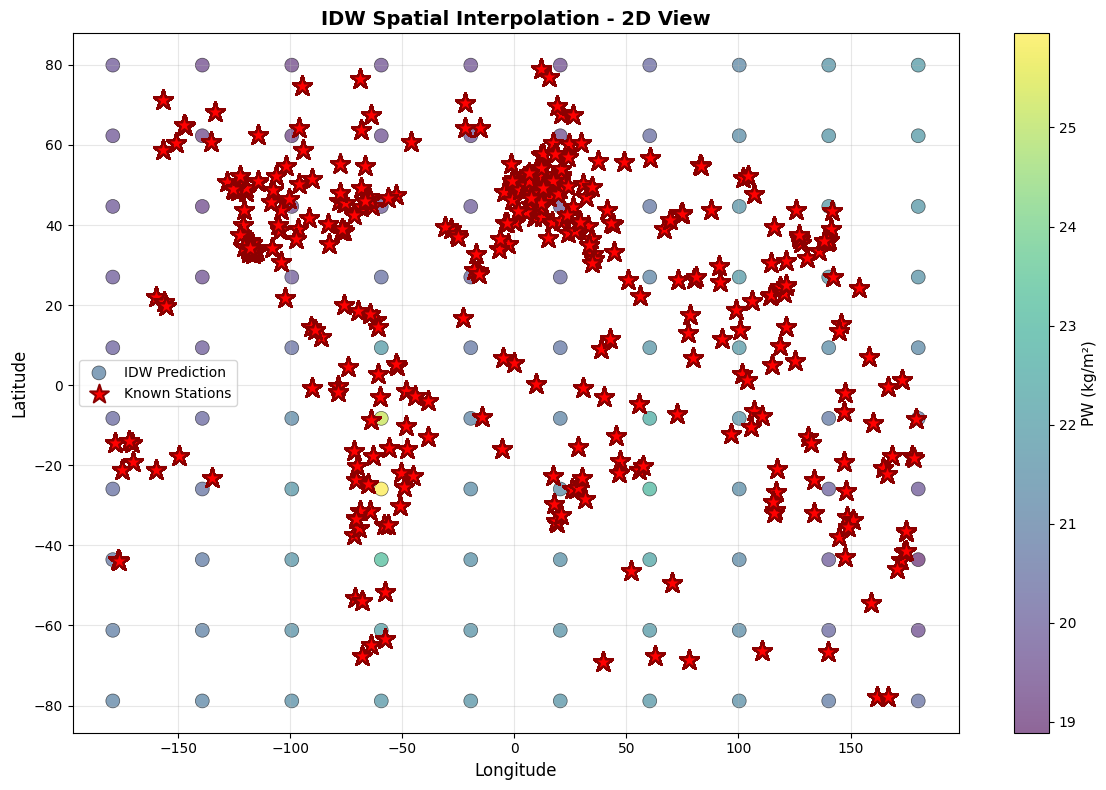

In [ ]:
# INVERSE DISTANCE WEIGHTING (IDW)
from scipy.spatial.distance import cdist

def idw_interpolation(known_coords, known_values, unknown_coords, power=2):
    """
    Inverse Distance Weighting interpolation
    power=2 is standard; higher power gives more weight to nearby points
    """
    distances = cdist(unknown_coords, known_coords, metric='euclidean')
    # Avoid division by zero for exact matches
    distances = np.where(distances == 0, 1e-10, distances)
    weights = 1 / (distances ** power)
    weights_sum = np.sum(weights, axis=1, keepdims=True)
    interpolated = np.sum(weights * known_values, axis=1) / weights_sum.flatten()
    return interpolated

if 'pivot_df' in globals():
    # Prepare known data
    known = pivot_df.dropna(subset=['longitude', 'latitude', 'station_elevation', 'PW'])
    known_coords = known[['longitude', 'latitude', 'station_elevation']].values
    known_values = known['PW'].values
    
    # Test points: grid around known stations
    lon_range = np.linspace(known['longitude'].min() - 1, known['longitude'].max() + 1, 10)
    lat_range = np.linspace(known['latitude'].min() - 1, known['latitude'].max() + 1, 10)
    elev_mean = known['station_elevation'].mean()
    
    # Create grid
    lon_grid, lat_grid = np.meshgrid(lon_range, lat_range)
    test_points = np.column_stack([lon_grid.flatten(), lat_grid.flatten(), 
                                   np.ones(len(lon_grid.flatten())) * elev_mean])
    
    # Apply IDW
    idw_predictions = idw_interpolation(known_coords, known_values, test_points, power=2)
    
    print(f"IDW Predictions (sample of 5): {idw_predictions[:5]}")
    print(f"IDW Range: {idw_predictions.min():.2f} to {idw_predictions.max():.2f} kg/m²")
    
    # Visualize IDW predictions on grid (2D)
    import matplotlib.pyplot as plt
    
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Plot interpolated points with PW values as colors
    scatter = ax.scatter(test_points[:, 0], test_points[:, 1], c=idw_predictions, 
                        cmap='viridis', s=100, alpha=0.6, label='IDW Prediction', edgecolors='black', linewidth=0.5)
    
    # Plot known stations on top
    ax.scatter(known['longitude'], known['latitude'], c='red', s=200, marker='*', 
              label='Known Stations', edgecolors='darkred', linewidth=1.5, zorder=5)
    
    ax.set_xlabel('Longitude', fontsize=12)
    ax.set_ylabel('Latitude', fontsize=12)
    ax.set_title('IDW Spatial Interpolation - 2D View', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10)
    
    # Add colorbar
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('PW (kg/m²)', fontsize=11)
    
    plt.tight_layout()
    plt.show()
else:
    print('pivot_df not defined. Run previous cells first.')